In [ ]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langfuse.langchain import CallbackHandler

load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
langfuse_trace = CallbackHandler()

# llm=init_chat_model(model='claude-sonnet-5', model_provider='anthropic')
llm=init_chat_model(model='claude-haiku-4-5-20251001', model_provider='anthropic')
ollama_llm = init_chat_model(
    model="granite4",
    model_provider="ollama"
)

llm
ollama_llm

d:\ai_learning\krisknaik\ultimate-rag-bootcamp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatOllama(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, model='granite4.1:8b')

In [2]:
from langchain_openai import OpenAIEmbeddings
from langchain_ollama import OllamaEmbeddings

# embeddings=OpenAIEmbeddings()
embeddings=OllamaEmbeddings(
    model="nomic-embed-text"
)
embeddings

OllamaEmbeddings(model='nomic-embed-text', dimensions=None, validate_model_on_init=False, base_url=None, client_kwargs={}, async_client_kwargs={}, sync_client_kwargs={}, mirostat=None, mirostat_eta=None, mirostat_tau=None, num_ctx=None, num_gpu=None, keep_alive=None, num_thread=None, repeat_last_n=None, repeat_penalty=None, temperature=None, stop=None, tfs_z=None, top_k=None, top_p=None)

In [3]:
## Document Ingestion And Processing
import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing_extensions import List, TypedDict

C:\Users\Tho Le\AppData\Local\Temp\ipykernel_26160\2862327239.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
# Load and chunk contents of the blog
loader = WebBaseLoader(
    web_path=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)

docs = loader.load()
docs

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [5]:
## chunking
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)
all_splits

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refi

In [6]:
from langchain_community.vectorstores import FAISS

vector_store = FAISS.from_documents(
    documents=all_splits,
    embedding=embeddings,
)

print(f"Vector store created with {vector_store.index.ntotal} vectors")

Vector store created with 63 vectors


In [7]:
from langchain_core.tools import tool

In [8]:
@tool()
def retrieve(query: str):
    """Retrieve the information related to the query"""

    retrieved_docs = vector_store.similarity_search(query, k=2)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in retrieved_docs
    )
    return (serialized, retrieved_docs)

In [9]:
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

In [10]:
# Step 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond."""
    llm_with_tools = llm.bind_tools([retrieve])
    response = llm_with_tools.invoke(state["messages"], config={"callbacks": [langfuse_trace]})
    # MessagesState appends messages to state instead of overwriting
    return {"messages": [response]}

In [11]:
# Step 2: Execute the retrieval.
tools = ToolNode([retrieve])
tools

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'retrieve': StructuredTool(name='retrieve', description='Retrieve the information related to the query', args_schema=<class 'langchain_core.utils.pydantic.retrieve'>, func=<function retrieve at 0x000002011D489940>)}, _injected_args={'retrieve': _InjectedArgs(state={}, store=None, runtime=None, all_injected_keys=set(), _optional_state_args=set())}, _handle_tool_errors=<function _default_handle_tool_errors at 0x00000201141C94E0>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None)

In [12]:
# Step 3: Generate a response using the retrieved content.
def generate(state: MessagesState):
    """Generate answer."""
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break
    tool_messages = recent_tool_messages[::-1]

    # Format into prompt
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages

    # Run
    response = llm.invoke(prompt, config={"callbacks": [langfuse_trace]})
    return {"messages": [response]}

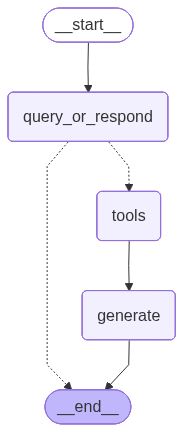

In [13]:
# Build graph
graph_builder = StateGraph(MessagesState)

graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)

graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"},
)
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
graph

In [14]:
# Specify an ID for the thread
config = {"configurable": {"thread_id": "abc123"}, "callbacks": [langfuse_trace]}

In [15]:
input_message="Hello"
for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()
    

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello! 👋 I'm here to help you. I have access to a retrieval tool that can find information for you. 

How can I assist you today? Feel free to ask me any questions or let me know what information you're looking for!


In [16]:
vector_store.similarity_search("What is TAsk Decomposition")

[Document(id='b5bd349f-bb1c-4d75-b4c5-cd61cc4984d2', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.\nTree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-f

In [17]:
input_message = "What is Task Decomposition?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================

[{'id': 'toolu_017u81cMcTY5jPuCNEEix1y8', 'caller': {'type': 'direct'}, 'input': {'query': 'Task Decomposition'}, 'name': 'retrieve', 'type': 'tool_use'}]
Tool Calls:
  retrieve (toolu_017u81cMcTY5jPuCNEEix1y8)
 Call ID: toolu_017u81cMcTY5jPuCNEEix1y8
  Args:
    query: Task Decomposition
================================= Tool Message =================================
Name: retrieve

('Source: {\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'}\nContent: Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” t

In [18]:
### Conversation History
chat_history=graph.get_state(config).values["messages"]
for message in chat_history:
    message.pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello! 👋 I'm here to help you. I have access to a retrieval tool that can find information for you. 

How can I assist you today? Feel free to ask me any questions or let me know what information you're looking for!
================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================

[{'id': 'toolu_017u81cMcTY5jPuCNEEix1y8', 'caller': {'type': 'direct'}, 'input': {'query': 'Task Decomposition'}, 'name': 'retrieve', 'type': 'tool_use'}]
Tool Calls:
  retrieve (toolu_017u81cMcTY5jPuCNEEix1y8)
 Call ID: toolu_017u81cMcTY5jPuCNEEix1y8
  Args:
    query: Task Decomposition
================================= Tool Message =================================
Name: retrieve

('Source: {\'source\': \'https://li

### ReAct Agent Architecture-Persistant Memory

In [19]:
retrieve

StructuredTool(name='retrieve', description='Retrieve the information related to the query', args_schema=<class 'langchain_core.utils.pydantic.retrieve'>, func=<function retrieve at 0x000002011D489940>)

In [20]:
from langchain.agents import create_agent

memory = MemorySaver()
agent_executor=create_agent(llm,[retrieve],checkpointer=memory)

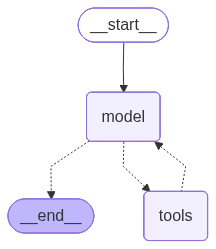

In [21]:
agent_executor

In [22]:
config = {"configurable": {"thread_id": "def234"}, "callbacks": [langfuse_trace]}

In [23]:
for event in agent_executor.stream({"messages": [{"role": "user", "content": input_message}]},
                                   stream_mode="values",
                                   config=config):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================

[{'id': 'toolu_01DQ85fJ52sLnikz1KhTtvYj', 'caller': {'type': 'direct'}, 'input': {'query': 'Task Decomposition'}, 'name': 'retrieve', 'type': 'tool_use'}]
Tool Calls:
  retrieve (toolu_01DQ85fJ52sLnikz1KhTtvYj)
 Call ID: toolu_01DQ85fJ52sLnikz1KhTtvYj
  Args:
    query: Task Decomposition
================================= Tool Message =================================
Name: retrieve

('Source: {\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'}\nContent: Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” t